# 1. Setup


## 1.1 Setup location and download necessary files


In [1]:
# Tests whether this is being done on colab vs a local jupyter notebook
try:
    import google.colab
    oncolab = True
except ImportError:
    oncolab = False

In [2]:
#Choose whether the code is run locally or on colab

if oncolab :
    import kagglehub
    path = kagglehub.dataset_download("bhavikardeshna/yahoo-email-classification")

else :
    rawdata = pd.read_csv("train.tsv", sep="\t")

100%|██████████| 309M/309M [00:02<00:00, 115MB/s]

Extracting files...


In [3]:
# !rm -rf '/content/Training_Classifier_on_Rare_Categories' #if repository needs to be removed

In [4]:
# Get git file

! git clone https://github.com/MPelland-programming/Training_Classifier_on_Rare_Categories.git

import sys
sys.path.append('/content/Training_Classifier_on_Rare_Categories')

Cloning into 'Training_Classifier_on_Rare_Categories'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 34 (delta 13), reused 28 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 5.20 KiB | 2.60 MiB/s, done.
Resolving deltas: 100% (13/13), done.


## 1.2 Installing and importing dependencies

In [7]:
if oncolab :
  ! pip install transformers
  ! pip install anthropic
  !pip install evaluate

  #!pip install evaluate

  #Import the model checkpoint (this will require authenticating )
  from google.colab import drive
  from google.colab import files
  drive.mount('/content/gdrive')
  #files.download('/content/gdrive/MyDrive/###name of checkpoint file###.txt')
  from google.colab import userdata
  apikey = userdata.get('ANTHROPIC_API_KEY')

import torch
import evaluate
import anthropic
from anthropic.types.messages.batch_create_params import Request
from anthropic.types.message_create_params import MessageCreateParamsNonStreaming
import numpy as np
import pandas as pd
#from Training_Classifier_on_Rare_Categories import claude_generation as cg #from my github
import time
from datasets import Dataset
from transformers import RobertaTokenizer, RobertaModel, RobertaForSequenceClassification,  Trainer, TrainingArguments
from transformers import AutoTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
from transformers import DataCollatorWithPadding

client = anthropic.Anthropic(api_key=apikey)

rng = np.random.default_rng(seed=42)

Mounted at /content/gdrive


In [8]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

## 1.3 Parameter choice

In [9]:
archi = "distilbert" # roberta or distilbert  is for training both models with limited amount of kaggle data.
sample_sizes = 1000 # Set to the amount of training data made available for the models
head = False     #Whether to train only the head
dataug = True    #Whether we are carrying data augmentation or not
dataugtype = "synthetic" #synthetic or human Whether dataaug is done on the synthetic or human data

if head:
  headstr = "head_only"
else:
  headstr = "all_weights"

model2train = "sonnet"     # epoch choice: https://consensus.app/papers/beyond-bert-exploring-the-efficacy-of-roberta-and-albert-in-sy-maceda/f6c116b5ffca56bc99ac41f87540058e/

if archi== "distilbert":
  training_args = TrainingArguments(eval_strategy="epoch", learning_rate=2e-4
                                  , per_device_train_batch_size=32,per_device_eval_batch_size=32
                                  , num_train_epochs = 2.0,output_dir="./results", report_to="none",)
if archi == "roberta":
    training_args = TrainingArguments(eval_strategy="epoch", learning_rate=2e-5
                                  , per_device_train_batch_size=32,per_device_eval_batch_size=32
                                  , num_train_epochs = 2.0,output_dir="./results", report_to="none",)



## 1.3 Load the test data

In [10]:
#dictionary of topics.
topic_dict = {
    "1":"Society_and_Culture"
    ,"2":"Science_and_Mathematics"
    #,"3":"Health"
    ,"4":"Education_and_Reference"
    #,"5":"Computers_and_Internet"
    #,"6":"Sports"
    #,"7":"Business_and_Finance"
    ,"8":"Entertainment_and_Music"
    ,"9":"Family_and_Relationships"
    #,"10":"Politics_and_Government"
}

In [11]:
#load test data
rawdata = pd.read_csv("/content/gdrive/MyDrive/yahoo_q_test.csv",header=None)

#create dataframe
cleandata = rawdata.iloc[:,[0,3]].astype(str).replace('nan', np.nan).dropna().rename(columns={0:"label",3:"text"})
clean_q = cleandata.iloc[:,-1].to_frame(name="text")

clean4sampling = cleandata.iloc[300:,:]
clean4sampling =clean4sampling[clean4sampling["label"].isin(["1","2","4","8","9"])]

print(rawdata.shape)
rawdata.head(3)

(60000, 4)


,0,1,2,3
0,9,What makes friendship click?,How does the spark keep going?,good communication is what does it. Can you m...
1,2,Why does Zebras have stripes?,What is the purpose or those stripes? Who do t...,this provides camouflage - predator vision is ...
2,4,What did the itsy bitsy sipder climb up?,NaN,waterspout


## 1.4 Get distribution of tokens

In [12]:
#tokenize all train data to get a distribution of token lenghts.
gensave = False
if gensave:
  from transformers import AutoTokenizer
  from datasets import Dataset

  tokenizer = AutoTokenizer.from_pretrained("RoBERTa-base")

  len_ds = Dataset.from_pandas(raw_q)
  opts = {'padding': False, 'truncation': True, 'max_length': 512}

  def tokenize_function(examples):
      return tokenizer(examples["text"], **opts)

  tokenized_datasets = len_ds.map(tokenize_function, batched=True)

  distr = np.array([len(ii["input_ids"]) for ii in tokenized_datasets])

  distr2 = distr[distr<512]

if gensave:
  np.save('DistributionTokNum.npy', distr2)
else :
  distr2 = np.load("/content/gdrive/MyDrive/DistributionTokNum.npy")

histcounts, histval = np.histogram(distr2, bins=508)
histprob = histcounts/sum(histcounts)

#line to provide
#rng.choice(val,p=prob)

In [ ]:
def generate_question_requests(topic, topic_id, q_context, exp_token, num_questions = 10
                               , max_tokens = 10):
    """
    :param q_context: context for question generation
    :param num_questions: number of questions to generate
    :param max_tokens: a list providing different max token limits for generation
    :return:
    """
     #random sampling from max_tokens

    #client = anthropic.Anthropic(api_key=apikey)

    reqlist=[]

    for ii in range(num_questions):

        reqlist.append(
            Request(
            custom_id="topic"+topic_id+"_q"+str(ii),
                params=MessageCreateParamsNonStreaming(
                    model="claude-haiku-4-5",
                    max_tokens=max_tokens,
                    system=[
                              {
                                "type": "text",
                                "text": "Here is a list of Yahoo ! Answers, each separated from the previous by 'Answers :'. They respond to questions about "+topic+" "+q_context,
                                "cache_control": {"type": "ephemeral"}
                              }
                            ],
                    messages=[{
                        "role": "user",

                        "content": "Generate an answer to a Yahoo! question about "+topic+". The answer should be around "+str(exp_tok[ii])+" tokens long. Do not provide que question nor prepend with Answer: . Simply provide an answer.",
                    }]
                )
            )
        )

    return reqlist

#"content": "Generate a Yahoo! Answer about "+topic+". Do not provide que question nor prepend with Answer: or with a summary of the context. Simply provide an answer.",

# 2. Generate text with claude and related dataset

## 2.1 Generate and load

In [13]:
gen_text = False
if gen_text:
  nq = 250
  it = 4   #how many times was data generated
  for topic_id in list(topic_dict.keys()):
  #for topic_id in ["2"]:
    # Get questions
    data_subset = cleandata[cleandata.iloc[:, 0] == topic_id].head(15).iloc[:,-1]
      # Generate context for batch processing.
    q_context = "Answer: "+" Answer: ".join(data_subset.astype(str).tolist())
    topic = topic_dict[topic_id]

    exp_tok = rng.choice(histval[:-1],p=histprob,size = nq).astype(int).tolist()

    req_list = generate_question_requests(topic, topic_id, q_context, exp_tok, num_questions = nq, max_tokens = 512)

    message_batch = client.messages.batches.create(requests=req_list)

    while True:
        curr_batch = client.messages.batches.retrieve(message_batch.id)
        if curr_batch.processing_status == "ended":
            break

        print(f"Batch {message_batch.id} is still processing...")
        time.sleep(30)

    tmp = []
    for aa in client.messages.batches.results(message_batch.id,):
      tmp.append(aa.result.message.content[0].text)

    pd.DataFrame(tmp).to_csv('/content/gdrive/MyDrive/DLGenData'+str(it)+'_'+topic+'.csv', index=False)

#to see results: for aa in client.messages.batches.results(message_batch.id,): aa.result.message.content[0].text

In [14]:
#it = 2
#bid = "msgbatch_01EfzUkAGAxirHpcUVHfCV8i"
#topic = "Sonnet_Society_and_Culture"
#tmp = []
#for aa in client.messages.batches.results(bid,):
#    tmp.append(aa.result.message.content[0].text)

#pd.DataFrame(tmp).to_csv('/content/gdrive/MyDrive/DLGenData'+str(it)+'_'+topic+'.csv', index=False)

In [15]:
# load claude data

haiku_text = []
haiku_labels = []

for topic_id in list(topic_dict.keys()):
  for it in range(1,5):
    haiku_text.append(pd.read_csv('/content/gdrive/MyDrive/DLGenData'+str(it)+"_"+topic_dict[topic_id]+'.csv',header=None)[1:])

  haiku_labels += [topic_id]*1000

son_text = []
son_labels = []

for topic_id in ["1","2"]:
  son_text.append(pd.read_csv('/content/gdrive/MyDrive/DLGenData_'+topic_dict[topic_id] +'_Sonnet.csv',header=None)[1:])

  son_labels += [topic_id]*1000


## 2.2 Datasets

In [ ]:
if not dataug:
  #Haiku dataset
  haiku_train_data = pd.concat(haiku_text).rename(columns = {0:"text"})
  haiku_train_data.insert(1,"label",haiku_labels)

  #Sonnet dataset
  son_train_data = pd.concat(son_text).rename(columns = {0:"text"})
  son_train_data.insert(1,"label",son_labels)

  #Split kaggle data into kaggle_train, valid, and test.
  tdata,kaggle_train_data = train_test_split(clean4sampling,test_size = sample_sizes*5, stratify = clean4sampling["label"], random_state=42)
  tdata,valid_data = train_test_split(tdata,test_size = 5000, stratify = tdata["label"], random_state=102)
  tdata,test_data = train_test_split(tdata,test_size = 5000, stratify = tdata["label"], random_state=12)

  #haiku_train_data =haiku_train_data[haiku_train_data["label"].isin(["1","2"])]##############################################################
  #kaggle_train_data =kaggle_train_data[kaggle_train_data["label"].isin(["1","2"])]#############################################################
  #valid_data =valid_data[valid_data["label"].isin(["1","2"])]###################################################################################
  #test_data =test_data[test_data["label"].isin(["1","2"])]#####################################################################################

  #Create kaggle_train, valid, and test for sonnet
  son_kaggle_train_data =kaggle_train_data[kaggle_train_data["label"].isin(["1","2"])]
  son_valid_data =valid_data[valid_data["label"].isin(["1","2"])]
  son_test_data =test_data[test_data["label"].isin(["1","2"])]

  #Generate datasets
  haiku_train_dataset = Dataset.from_pandas(haiku_train_data)
  kaggle_train_dataset = Dataset.from_pandas(kaggle_train_data)
  valid_dataset = Dataset.from_pandas(valid_data)
  test_dataset = Dataset.from_pandas(test_data)

  son_train_dataset = Dataset.from_pandas(son_train_data)
  son_kaggle_train_dataset = Dataset.from_pandas(son_kaggle_train_data)
  son_valid_dataset = Dataset.from_pandas(son_valid_data)
  son_test_dataset = Dataset.from_pandas(son_test_data)

# 3. Tokenize datsets and train model

## 3.2 Tokenizing

In [ ]:
# create tokenizer
if archi == "roberta":
  tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

if archi == "distilbert":
  tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased",return_tensors="pt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#Tokenize datasets
tok_opts = {"max_length":512,"padding":"max_length", "truncation":True, "return_tensors":"pt"}
labels = ["1","2","4","8","9"]

haiku_train_dataset = haiku_train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
haiku_train_dataset = haiku_train_dataset.cast_column('label', ClassLabel(names=labels))

kaggle_train_dataset = kaggle_train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
kaggle_train_dataset = kaggle_train_dataset.cast_column('label', ClassLabel(names=labels))

valid_dataset = valid_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
valid_dataset = valid_dataset.cast_column('label', ClassLabel(names=labels))

test_dataset = test_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
test_dataset = test_dataset.cast_column('label', ClassLabel(names=labels))

son_train_dataset = son_train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
son_train_dataset = son_train_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

son_kaggle_train_dataset = son_kaggle_train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
son_kaggle_train_dataset = son_kaggle_train_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

son_valid_dataset = son_valid_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
son_valid_dataset = son_valid_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

son_test_dataset = son_test_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
son_test_dataset = son_test_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/129 [00:00<?, ? examples/s]

Map:   0%|          | 0/2022 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2022 [00:00<?, ? examples/s]

Map:   0%|          | 0/2022 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2022 [00:00<?, ? examples/s]

## 3.3 Model spec

### 3.3.1 Distilbert

In [ ]:
#Create the models
if archi == "distilbert":
  if model2train =="haiku":
    #Haiku#
    haiku_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5
                                                                      , device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in haiku_model.parameters():
          param.requires_grad=False

      for param in haiku_model.classifier.parameters():
        param.requires_grad=True


    #kaggle#
    kaggle_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5
                                                                      , device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in kaggle_model.parameters():
          param.requires_grad=False

      for param in kaggle_model.classifier.parameters():
        param.requires_grad=True


  if model2train =="sonnet":
    #sonnet#
    son_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2
                                                                      , device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in son_model.parameters():
          param.requires_grad=False

      for param in son_model.classifier.parameters():
        param.requires_grad=True

    #kaggl4 sonnet#
    son_kaggle_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2
                                                                      , device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in son_kaggle_model.parameters():
          param.requires_grad=False

      for param in son_kaggle_model.classifier.parameters():
        param.requires_grad=True


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 3.3.2 Roberta

In [ ]:
#Create the models
if archi == "roberta":
  if model2train =="haiku":
    #Haiku#
    haiku_model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=5,device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in haiku_model.parameters():
          param.requires_grad=False

      for param in haiku_model.classifier.parameters():
        param.requires_grad=True


    #kaggle#
    kaggle_model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=5,device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in kaggle_model.parameters():
          param.requires_grad=False

      for param in kaggle_model.classifier.parameters():
        param.requires_grad=True


  if model2train =="sonnet":
    #sonnet#
    son_model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=2,device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in son_model.parameters():
          param.requires_grad=False

      for param in son_model.classifier.parameters():
        param.requires_grad=True

    #kaggl4 sonnet#
    son_kaggle_model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=2,device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in son_kaggle_model.parameters():
          param.requires_grad=False

      for param in son_kaggle_model.classifier.parameters():
        param.requires_grad=True


### 3.3.3 sample sizes

In [ ]:
if archi == "roberta":
  if model2train == "sampling_sizes":
    #kaggle#
    kaggle_model5 = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=5,device_map="auto",dtype="auto")
    kaggle_model2 = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=2,device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in kaggle_model5.parameters():
          param.requires_grad=False

      for param in kaggle_model2.classifier.parameters():
        param.requires_grad=True

if archi == "distilbert":
  if model2train == "sampling_sizes":
    #kaggle#
    kaggle_model5 = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5
                                                                      , device_map="auto",dtype="auto")

    kaggle_model2 =  DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2
                                                                      , device_map="auto",dtype="auto")

    #Make only head trainable
    if head:
      for param in kaggle_model5.parameters():
          param.requires_grad=False

      for param in kaggle_model2.classifier.parameters():
        param.requires_grad=True


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 3.4 Training

### 3.4.1 haiku

In [ ]:
if model2train =="haiku":
  # training haiku
  haiku_trainer = Trainer(args = training_args
                      , model = haiku_model
                      , train_dataset = haiku_train_dataset
                      , eval_dataset = valid_dataset
                      , data_collator=data_collator
                      #, run_name="haiku_"+archi+"_"+headstr

                  )

  haiku_trainer.train()

In [ ]:
if model2train =="haiku":
  # training kaggle

  kaggle_trainer = Trainer(args = training_args
                      , model = kaggle_model
                      , train_dataset = kaggle_train_dataset
                      , eval_dataset = valid_dataset
                      , data_collator=data_collator
                      #, run_name="kaggle_"+archi+"_"+headstr

                  )

  kaggle_trainer.train()

### 3.4.2 Sonnet

In [ ]:
if model2train =="sonnet":
  # training son
  son_trainer = Trainer(args = training_args
                      , model = son_model
                      , train_dataset = son_train_dataset
                      , eval_dataset = son_valid_dataset
                      , data_collator=data_collator
                      #, run_name="son_"+archi+"_"+headstr

                  )

  son_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.


Epoch,Training Loss,Validation Loss
1,No log,0.767599
2,No log,0.858950


In [ ]:
if model2train =="sonnet":
  # training son

  son_kaggle_trainer = Trainer(args = training_args
                      , model = son_kaggle_model
                      , train_dataset = son_kaggle_train_dataset
                      , eval_dataset = son_valid_dataset
                      , data_collator=data_collator
                      #, run_name="son_kaggle_"+archi+"_"+headstr

                  )

  son_kaggle_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.


Epoch,Training Loss,Validation Loss
1,No log,0.531456
2,No log,0.354962


### 3.4.3 Sample sizes

In [ ]:
if archi == "sampling_sizes":
  kaggle_trainer5 = Trainer(args = training_args
                      , model = kaggle_model5
                      , train_dataset = kaggle_train_dataset
                      , eval_dataset = valid_dataset
                      , data_collator=data_collator
                      #, run_name="son_kaggle_"+archi+"_"+headstr

                  )

  kaggle_trainer5.train()

  kaggle_trainer2 = Trainer(args = training_args
                      , model = kaggle_model2
                      , train_dataset = son_kaggle_train_dataset
                      , eval_dataset = son_valid_dataset
                      , data_collator=data_collator
                      #, run_name="son_kaggle_"+archi+"_"+headstr

                  )

  kaggle_trainer2.train()

## 3.5 Eval

### 3.5.1 Haiku

In [ ]:
if model2train =="haiku":
  def haiku_predict(inp):
      temp_class = haiku_model(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"haiku_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  def kaggle_predict(inp):
      temp_class = kaggle_model(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"kaggle_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  test_dataset = test_dataset.map(lambda inp : haiku_predict(inp)
                                  ,batched = True
                                  ,batch_size = 32
                                )

  test_dataset = test_dataset.map(lambda inp : kaggle_predict(inp)
                                  ,batched = True
                                  ,batch_size = 32
                                )

### 3.5.2 Sonnet

In [ ]:
if model2train =="sonnet":
  def son_predict(inp):
      temp_class = son_model(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"son_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  def son_kaggle_predict(inp):
      temp_class = son_kaggle_model(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"son_kaggle_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  test_dataset = test_dataset.map(lambda inp : son_predict(inp)
                                ,batched = True
                                ,batch_size = 32
                               )

  son_test_dataset = son_test_dataset.map(lambda inp : son_kaggle_predict(inp)
                                ,batched = True
                                ,batch_size = 32
                               )


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2022 [00:00<?, ? examples/s]

### 3.5.3 Sample sizes

In [ ]:
if model2train =="sampling_sizes":
  def kaggle_predict5(inp):
      temp_class = kaggle_model5(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"kaggle5_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  def kaggle_predict2(inp):
      temp_class = kaggle_model(input_ids = torch.tensor(inp["input_ids"]).to(device)
                    ,attention_mask = torch.tensor(inp["attention_mask"]).to(device)
                  ).logits
      outclass = {"kaggle2_predict": torch.argmax(temp_class,dim = 1)}

      return outclass

  test_dataset = test_dataset.map(lambda inp : kaggle_predict5(inp)
                                ,batched = True
                                ,batch_size = 32
                               )

  son_test_dataset = son_test_dataset.map(lambda inp : kaggle_predict2(inp)
                                ,batched = True
                                ,batch_size = 32
                               )

# 4. Results

In [ ]:
accuracy_metric = evaluate.load("accuracy")
confusion_metric = evaluate.load("confusion_matrix")

## Haiku

In [ ]:
if model2train =="haiku":
  #haiku results
  print('Results haiku '+archi+' '+headstr)
  acc_results = accuracy_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["haiku_predict"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["haiku_predict"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")


  #kaggle results
  print('Results kaggle '+archi+' '+headstr)
  acc_results = accuracy_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["kaggle_predict"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["kaggle_predict"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")

## Sonnet

In [ ]:
  print('Results son kaggle '+archi+' '+headstr)
  acc_results = accuracy_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["son_kaggle_predict"])
  print("accurary: "+str(acc_results))

Results son kaggle distilbert all_weights
accurary: {'accuracy': 0.8570722057368941}


In [ ]:
if model2train =="sonnet":
  #sonresults
  print('Results son '+archi+' '+headstr)
  acc_results = accuracy_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["son_predict"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["son_predict"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")



  #sonresults
  print('Results son kaggle '+archi+' '+headstr)
  acc_results = accuracy_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["son_kaggle_predict"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["son_kaggle_predict"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")

Results son distilbert all_weights


KeyError: 'son_predict'

## Samples sizes

In [ ]:
if model2train =="sampling_sizes":
  #sonresults
  print('Results kaggle5 '+archi+' '+headstr+' '+str(sample_sizes))
  acc_results = accuracy_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["kaggle_predict5"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=test_dataset[:]["label"], predictions=test_dataset[:]["kaggle_predict5"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")



  #sonresults
  print('Results kaggle2 '+archi+' '+headstr+' '+str(sample_sizes))
  acc_results = accuracy_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["kaggle_predict2"])
  print("accurary: "+str(acc_results))

  conf_results = confusion_metric.compute(references=son_test_dataset[:]["label"], predictions=son_test_dataset[:]["kaggle_predict2"])
  print("Confusion matrix: "+str(conf_results)+"\n\n")

In [ ]:
# Save datasets
if model2train == "haiku":
  print_dataset = test_dataset.remove_columns(["input_ids","attention_mask","__index_level_0__"])
  print_dataset.to_csv('/content/gdrive/MyDrive/DLResults_'+model2train+'_'+archi+'_'+headstr+'.csv')

if model2train == "sonnet":
  print_dataset = son_test_dataset.remove_columns(["input_ids","attention_mask","__index_level_0__"])
  print_dataset.to_csv('/content/gdrive/MyDrive/DLResults_'+model2train+'_'+archi+'_'+headstr+'.csv')


Creating CSV from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

1784921

# Data augmentation

In [16]:
if dataug:

  if dataugtype == "synthetic":
  #Sonnet dataset
    train_data = pd.concat(son_text).rename(columns = {0:"text"})
    train_data.insert(1,"label",son_labels)

    train_dataset = Dataset.from_pandas(train_data)

  #Split kaggle data into kaggle_train, valid, and test.
  tdata,kaggle_train_data = train_test_split(clean4sampling,test_size = sample_sizes*5, stratify = clean4sampling["label"], random_state=42)
  tdata,valid_data = train_test_split(tdata,test_size = 500, stratify = tdata["label"], random_state=102)
  tdata,test_data = train_test_split(tdata,test_size = 500, stratify = tdata["label"], random_state=12)

  if dataugtype == "human":
    train_data =kaggle_train_data[kaggle_train_data["label"].isin(["1","2"])]
    train_dataset = Dataset.from_pandas(son_kaggle_train_data)

  #Create kaggle_train, valid, and test for sonnet
  valid_data =valid_data[valid_data["label"].isin(["1","2"])]
  test_data =test_data[test_data["label"].isin(["1","2"])]


  valid_dataset = Dataset.from_pandas(valid_data)
  test_dataset = Dataset.from_pandas(test_data)

In [17]:
if dataug:
    # create tokenizer
  if archi == "roberta":
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

  if archi == "distilbert":
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased",return_tensors="pt")

  #Tokenize datasets
  tok_opts = {"max_length":512,"padding":"max_length", "truncation":True, "return_tensors":"pt"}
  labels = ["1","2","4","8","9"]

  if dataugtype == "synthetic":
    train_dataset = train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
    train_dataset = train_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

  if dataugtype == "human":
    train_dataset = train_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
    train_dataset = train_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

  valid_dataset = valid_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
  valid_dataset = valid_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

  test_dataset = test_dataset.map(lambda datain: tokenizer(datain["text"],**tok_opts), batched=True, batch_size=1000)
  test_dataset = test_dataset.cast_column('label', ClassLabel(names=labels[0:2]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

In [18]:
if dataug:
  #Create the models
  if archi == "distilbert":
    if dataugtype == "synthetic":

      #sonnet#
      model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2
                                                                        , device_map="auto",dtype="auto")

      #Make only head trainable
      if head:
        for param in model.parameters():
            param.requires_grad=False

        for param in model.classifier.parameters():
          param.requires_grad=True

    if dataugtype == "human":

      #kaggl4 sonnet#
      model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2
                                                                        , device_map="auto",dtype="auto")

      #Make only head trainable
      if head:
        for param in model.parameters():
            param.requires_grad=False

        for param in model.classifier.parameters():
          param.requires_grad=True

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
if dataug:
  def apply_masking(batch, mask_prob=0.3, mask_id=103):
      input_ids = torch.tensor(batch["input_ids"])
      mask = torch.rand(input_ids.shape) < mask_prob
      input_ids[mask] = mask_id
      attention_mask = torch.tensor(batch["attention_mask"])
      return {"input_ids": input_ids, "label": torch.tensor(batch["label"]),"attention_mask": attention_mask}

  train_dataset.set_transform(lambda x: apply_masking(x))

In [33]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = torch.stack([item["input_ids"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    attention_mask = torch.stack([item["attention_mask"] for item in batch])
    return input_ids, labels, attention_mask

val_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [34]:
if dataug:
  criterion = nn.CrossEntropyLoss()

  for epoch in range(5):
      model.train()
      train_loss = 0.0
      train_correct = 0
      train_total = 0

      for data, labels, attention_mask in train_loader:
          data, labels, attention_mask = data.to(device), labels.to(device), attention_mask.to(device)

          optimizer.zero_grad()
          outputs = model(input_ids=data, attention_mask=attention_mask)
          loss = criterion(outputs.logits, labels)
          loss.backward()
          optimizer.step()

          train_loss += loss.item()
          predictions = outputs.logits.argmax(dim=-1)
          train_correct += predictions.eq(labels).sum().item()
          train_total += labels.size(0)

      train_error = 1 - (train_correct / train_total)

      # Validation
      model.eval()
      val_correct = 0
      val_total = 0
      val_loss = 0.0

      with torch.no_grad():
          for data, labels, attention_mask in val_loader:
              data, labels, attention_mask = data.to(device), labels.to(device), attention_mask.to(device)
              outputs = model(input_ids=data, attention_mask=attention_mask)
              loss = criterion(outputs.logits, labels)
              val_loss += loss.item()
              predictions = outputs.logits.argmax(dim=-1)
              val_correct += predictions.eq(labels).sum().item()
              val_total += labels.size(0)

      val_error = 1 - (val_correct / val_total)

      print(f'Epoch {epoch+1}/5:')
      print(f'  Training Error: {train_error:.4f} (Loss: {train_loss/len(train_loader):.4f})')
      print(f'  Validation Error: {val_error:.4f} (Loss: {val_loss/len(val_loader):.4f})')

ValueError: too many values to unpack (expected 3)

In [30]:
if dataug:# Training loop
  criterion = nn.CrossEntropyLoss()

  for epoch in range(5):
      # Apply fresh masking each epoch

      model.train()
      train_loss = 0.0
      train_correct = 0
      train_total = 0


      for data, labels,attention_mask in train_loader:

          data, labels, attention_mask = data.to(device), labels.to(device), attention_mask.to(device)

          optimizer.zero_grad()
          outputs = model(input_ids=data, labels=labels, attention_mask = attention_mask)
          print(outputs)
          loss = criterion(outputs.logits.argmax(dim=-1).float(), labels.float())
          loss.backward()
          optimizer.step()

          train_loss += loss.item()
          train_correct += outputs.argmax(1).eq(labels).sum().item()
          train_total += labels.size(0)

      train_error = 1 - (train_correct / train_total)

      # Validation
      model.eval()
      val_correct = 0
      val_total = 0
      val_loss = 0.0

      with torch.no_grad():
          for data, labels in val_loader:
              data, labels = data.to(device), labels.to(device)
              outputs = model(data)
              val_loss += criterion(outputs, labels).item()
              val_correct += outputs.argmax(1).eq(labels).sum().item()
              val_total += labels.size(0)

      val_error = 1 - (val_correct / val_total)

      print(f'Epoch {epoch+1}/5:')
      print(f'  Training Error: {train_error:.4f} (Loss: {train_loss/len(train_loader):.4f})')
      print(f'  Validation Error: {val_error:.4f} (Loss: {val_loss/len(val_loader):.4f})')

SequenceClassifierOutput(loss=tensor(0.6169, device='cuda:0', grad_fn=<NllLossBackward0>), logits=tensor([[ 0.2237, -0.0025],
        [ 0.1097,  0.0076],
        [ 0.1098,  0.1829],
        [ 0.1989,  0.0467],
        [ 0.1872, -0.0266],
        [ 0.1641,  0.0341],
        [ 0.1035, -0.0734],
        [ 0.2724, -0.1005]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

# important notes
Prestest shows that we already get into overfitting by epoch 2.

# figures

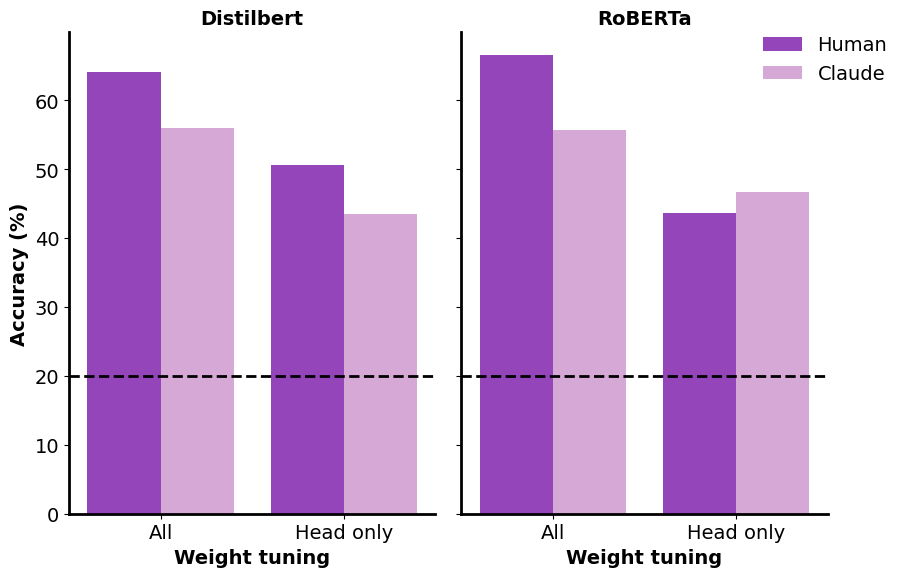

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_context(rc={'axes.linewidth': 2,'font.size': 14})


# Your 2x2x2 design data (single value per condition)
data = {
    'Weight tuning': ['All'       , 'All'       , 'All'    , 'All'    , 'Head only' , 'Head only', 'Head only', 'Head only'],
    'Model':         ['DistilBERT','DistilBERT' , 'RoBERTa', 'RoBERTa', 'DistilBERT','DistilBERT', 'RoBERTa'  , 'RoBERTa'],
    'Training data': ['Human'     , 'Haiku'    , 'Human'  , 'Haiku' , 'Human'     , 'Haiku'   , 'Human'    , 'Haiku'],
    'Accuracy':      [64.12       , 56.0        , 66.5     , 55.6     , 50.6          , 43.43        , 43.6         , 46.7]  # Your single input values
}

df = pd.DataFrame(data)

# Alternative: Use FacetGrid for clearer 2x2x2 visualization
g = sns.FacetGrid(df, col='Model', height=6, aspect=0.6)
g.map_dataframe(sns.barplot, x='Weight tuning', y='Accuracy', hue='Training data',
                palette=["darkorchid","plum"], errorbar=None
                , dodge = True)
g.add_legend(bbox_to_anchor=(.88, .95), loc='upper left')

g.set_axis_labels('Weight tuning', 'Accuracy (%)', fontsize = 14, fontweight = 'bold')
g.set_titles('{col_name}', fontsize = 16, fontweight = 'bold')
ax1, ax2 = g.axes[0]
ax1.axhline(y=20, color='black', linestyle='--', linewidth=2)
ax2.axhline(y=20, color='black', linestyle='--', linewidth=2)
plt.tight_layout()

plt.savefig('my_plot.png', dpi=300)

plt.show()

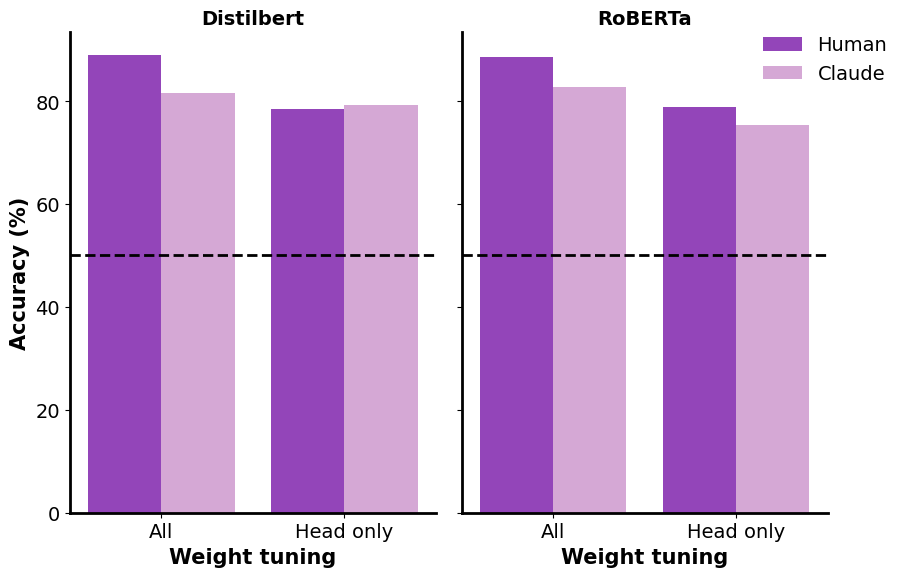

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_context(rc={'axes.linewidth': 2,'font.size': 14})


# Your 2x2x2 design data (single value per condition)
data = {
    'Weight tuning': ['All'       , 'All'       , 'All'       , 'All'    , 'All'    , 'All'       ,'Head only' , 'Head only' ,'Head only' ,  'Head only', 'Heal only', 'Head only'],
    'Model':         ['DistilBERT','DistilBERT' , 'DistilBERT', 'RoBERTa', 'RoBERTa', 'RoBERTa'   , 'DistilBERT','DistilBERT','DistilBERT',  'RoBERTa'  , 'RoBERTa'  ,  'RoBERTa'],
    'Training data': ['Human'     ,'Sonnet'     , 'Haiku'     , 'Human'  , 'Sonnet' , 'Haiku'    , 'Human'     , 'Sonnet'    , 'Haiku'    ,  'Human'    , 'Sonnet'   ,  'Haiku'],
    'Accuracy':      [88.9       , 81.5         , 83.0        , 88.6     , 82.8     ,  82.3      , 78.5          , 79.3      , 75.3        , 78.9       , 75.4       ,  80.0]  # Your single input values
}

df = pd.DataFrame(data)

# Alternative: Use FacetGrid for clearer 2x2x2 visualization
g = sns.FacetGrid(df, col='Model', height=6, aspect=0.6)
g.map_dataframe(sns.barplot, x='Weight tuning', y='Accuracy', hue='Training data',
                palette=["darkorchid","plum"], errorbar=None
                , dodge = True)
g.add_legend(bbox_to_anchor=(.88, .95), loc='upper left')

g.set_axis_labels('Weight tuning', 'Accuracy (%)', fontsize = 15, fontweight = 'bold')
g.set_titles('{col_name}', fontsize = 16, fontweight = 'bold')
ax1, ax2 = g.axes[0]
ax1.axhline(y=50, color='black', linestyle='--', linewidth=2)
ax2.axhline(y=50, color='black', linestyle='--', linewidth=2)
plt.tight_layout()

plt.show()

/tmp/ipython-input-2524524936.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Column', y='Accuracy', palette=["darkorchid"], errorbar=None)
/tmp/ipython-input-2524524936.py:18: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_plot, x='Column', y='Accuracy', palette=["darkorchid"], errorbar=None)


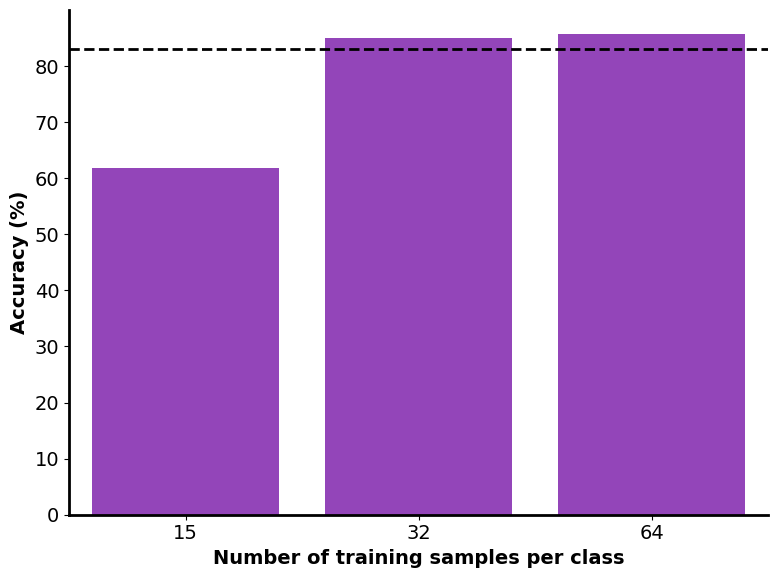

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_context(rc={'axes.linewidth': 2,'font.size': 14})

data = {
    '15': [61.85],
    '32': [85.0],
    '64': [85.7]
}

df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
df_plot = df.melt(var_name='Column', value_name='Accuracy')
sns.barplot(data=df_plot, x='Column', y='Accuracy', palette=["darkorchid"], errorbar=None)
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.xlabel('Number of training samples per class', fontsize=14, fontweight='bold')
plt.axhline(y=83, color='black', linestyle='--', linewidth=2)
sns.despine()
plt.tight_layout()

plt.show()

# Test lines

In [ ]:
#see https://docs.claude.com/en/docs/build-with-claude/batch-processing